In [3]:
# Credit Risk Analysis - German Dataset

## Objective: Menganalisis faktor-faktor yang mempengaruhi risiko kredit dan membangun model prediksi untuk mengidentifikasi nasabah berisiko.

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier

In [5]:
col_names = [
'Status', 'Duration', 'Credit_History', 'Purpose', 'Credit_Amount',
'Savings', 'Employment_Duration', 'Installment_Rate',
'Personal_Status_Sex', 'Other_Debtors', 'Residence_Since',
'Property', 'Age', 'Other_Installment_Plans', 'Housing',
'Number_Credits', 'Job', 'People_Liable', 'Telephone',
'Foreign_Worker', 'Risk'
]

df = pd.read_csv(r"C:\Laila\Belajar Data Analyst\Python\german.data", sep=' ', header=None, names=col_names)

df.head()

,Status,Duration,Credit_History,Purpose,Credit_Amount,Savings,Employment_Duration,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Number_Credits,Job,People_Liable,Telephone,Foreign_Worker,Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [6]:
df.shape #data validation

(1000, 21)

In [7]:
df['Risk'].value_counts() 

Risk
1    700
2    300
Name: count, dtype: int64

In [8]:
df['Risk'] = df['Risk'].map({1: 'good', 2: 'bad'})

In [9]:
df

,Status,Duration,Credit_History,Purpose,Credit_Amount,Savings,Employment_Duration,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Number_Credits,Job,People_Liable,Telephone,Foreign_Worker,Risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,good
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,bad
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,good
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,good
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,good
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,good
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,good
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,bad


In [10]:
df.info() #there's no missing value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Status                   1000 non-null   object
 1   Duration                 1000 non-null   int64 
 2   Credit_History           1000 non-null   object
 3   Purpose                  1000 non-null   object
 4   Credit_Amount            1000 non-null   int64 
 5   Savings                  1000 non-null   object
 6   Employment_Duration      1000 non-null   object
 7   Installment_Rate         1000 non-null   int64 
 8   Personal_Status_Sex      1000 non-null   object
 9   Other_Debtors            1000 non-null   object
 10  Residence_Since          1000 non-null   int64 
 11  Property                 1000 non-null   object
 12  Age                      1000 non-null   int64 
 13  Other_Installment_Plans  1000 non-null   object
 14  Housing                  1000 non-null   

In [11]:
df.describe() #### Insight: Sebagian besar nasabah memiliki durasi kredit sekitar 18–24 bulan dengan nilai kredit rata-rata sekitar 3.200 DM. Namun, terdapat variasi yang cukup besar terutama pada Credit Amount, yang mengindikasikan adanya perbedaan signifikan antar nasabah dalam jumlah pinjaman.Selain itu, jumlah kredit yang dimiliki nasabah relatif kecil (mayoritas ≤ 2), yang menunjukkan bahwa sebagian besar nasabah tidak memiliki banyak kredit aktif secara bersamaan.

,Duration,Credit_Amount,Installment_Rate,Residence_Since,Age,Number_Credits,People_Liable
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [12]:
df.duplicated().sum()

np.int64(0)

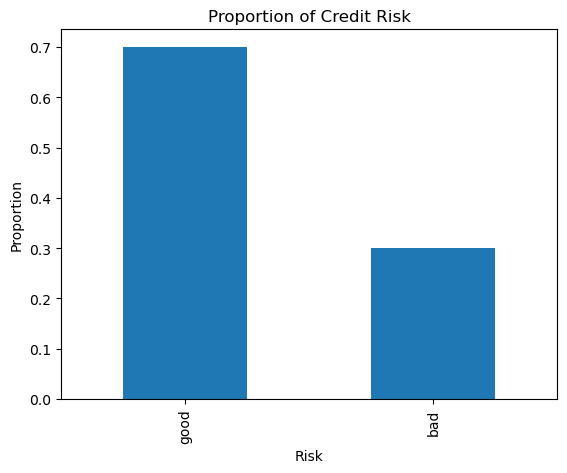

In [14]:
df['Risk'].value_counts(normalize=True).plot(kind='bar')

plt.title('Proportion of Credit Risk')
plt.xlabel('Risk')
plt.ylabel('Proportion')

plt.show()

### Insight: Distribusi data menunjukkan bahwa sekitar 70% nasabah tergolong dalam kategori good dan 30% dalam kategori bad. Hal ini menunjukkan adanya class imbalance, yang penting diperhatikan dalam proses modeling karena model cenderung bias terhadap kelas mayoritas.

In [15]:
df['Status'].unique()

array(['A11', 'A12', 'A14', 'A13'], dtype=object)

In [16]:
status_map = {
    'A11': '<0 DM',
    'A12': '0-200 DM',
    'A13': '>=200 DM',
    'A14': 'no_account'
}

df['Status'] = df['Status'].map(status_map)

In [17]:
df

,Status,Duration,Credit_History,Purpose,Credit_Amount,Savings,Employment_Duration,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Number_Credits,Job,People_Liable,Telephone,Foreign_Worker,Risk
0,<0 DM,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,good
1,0-200 DM,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,bad
2,no_account,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,good
3,<0 DM,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,good
4,<0 DM,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no_account,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,good
996,<0 DM,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,good
997,no_account,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,good
998,<0 DM,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,bad


In [18]:
df['Savings'].unique()

array(['A65', 'A61', 'A63', 'A64', 'A62'], dtype=object)

In [19]:
savings_map = {
    'A61': '<100 DM',
    'A62': '100-500 DM',
    'A63': '500-1000 DM',
    'A64': '>=1000 DM',
    'A65': 'no_savings'
}

df['Savings'] = df['Savings'].map(savings_map)
df

,Status,Duration,Credit_History,Purpose,Credit_Amount,Savings,Employment_Duration,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Number_Credits,Job,People_Liable,Telephone,Foreign_Worker,Risk
0,<0 DM,6,A34,A43,1169,no_savings,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,good
1,0-200 DM,48,A32,A43,5951,<100 DM,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,bad
2,no_account,12,A34,A46,2096,<100 DM,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,good
3,<0 DM,42,A32,A42,7882,<100 DM,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,good
4,<0 DM,24,A33,A40,4870,<100 DM,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no_account,12,A32,A42,1736,<100 DM,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,good
996,<0 DM,30,A32,A41,3857,<100 DM,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,good
997,no_account,12,A32,A43,804,<100 DM,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,good
998,<0 DM,45,A32,A43,1845,<100 DM,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,bad


In [20]:
df['Housing'].unique()

array(['A152', 'A153', 'A151'], dtype=object)

In [21]:
housing_map = {
    'A151': 'rent',
    'A152': 'own',
    'A153': 'free'
}

df['Housing'] = df['Housing'].map(housing_map)
df

,Status,Duration,Credit_History,Purpose,Credit_Amount,Savings,Employment_Duration,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Number_Credits,Job,People_Liable,Telephone,Foreign_Worker,Risk
0,<0 DM,6,A34,A43,1169,no_savings,A75,4,A93,A101,...,A121,67,A143,own,2,A173,1,A192,A201,good
1,0-200 DM,48,A32,A43,5951,<100 DM,A73,2,A92,A101,...,A121,22,A143,own,1,A173,1,A191,A201,bad
2,no_account,12,A34,A46,2096,<100 DM,A74,2,A93,A101,...,A121,49,A143,own,1,A172,2,A191,A201,good
3,<0 DM,42,A32,A42,7882,<100 DM,A74,2,A93,A103,...,A122,45,A143,free,1,A173,2,A191,A201,good
4,<0 DM,24,A33,A40,4870,<100 DM,A73,3,A93,A101,...,A124,53,A143,free,2,A173,2,A191,A201,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no_account,12,A32,A42,1736,<100 DM,A74,3,A92,A101,...,A121,31,A143,own,1,A172,1,A191,A201,good
996,<0 DM,30,A32,A41,3857,<100 DM,A73,4,A91,A101,...,A122,40,A143,own,1,A174,1,A192,A201,good
997,no_account,12,A32,A43,804,<100 DM,A75,4,A93,A101,...,A123,38,A143,own,1,A173,1,A191,A201,good
998,<0 DM,45,A32,A43,1845,<100 DM,A73,4,A93,A101,...,A124,23,A143,free,1,A173,1,A192,A201,bad


In [22]:
df['Job'].unique()

array(['A173', 'A172', 'A174', 'A171'], dtype=object)

In [23]:
job_map = {
    'A171': 'unemployed/unskilled_non_resident',
    'A172': 'unskilled_resident',
    'A173': 'skilled',
    'A174': 'highly_skilled'
}

df['Job'] = df['Job'].map(job_map)
df

,Status,Duration,Credit_History,Purpose,Credit_Amount,Savings,Employment_Duration,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Number_Credits,Job,People_Liable,Telephone,Foreign_Worker,Risk
0,<0 DM,6,A34,A43,1169,no_savings,A75,4,A93,A101,...,A121,67,A143,own,2,skilled,1,A192,A201,good
1,0-200 DM,48,A32,A43,5951,<100 DM,A73,2,A92,A101,...,A121,22,A143,own,1,skilled,1,A191,A201,bad
2,no_account,12,A34,A46,2096,<100 DM,A74,2,A93,A101,...,A121,49,A143,own,1,unskilled_resident,2,A191,A201,good
3,<0 DM,42,A32,A42,7882,<100 DM,A74,2,A93,A103,...,A122,45,A143,free,1,skilled,2,A191,A201,good
4,<0 DM,24,A33,A40,4870,<100 DM,A73,3,A93,A101,...,A124,53,A143,free,2,skilled,2,A191,A201,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no_account,12,A32,A42,1736,<100 DM,A74,3,A92,A101,...,A121,31,A143,own,1,unskilled_resident,1,A191,A201,good
996,<0 DM,30,A32,A41,3857,<100 DM,A73,4,A91,A101,...,A122,40,A143,own,1,highly_skilled,1,A192,A201,good
997,no_account,12,A32,A43,804,<100 DM,A75,4,A93,A101,...,A123,38,A143,own,1,skilled,1,A191,A201,good
998,<0 DM,45,A32,A43,1845,<100 DM,A73,4,A93,A101,...,A124,23,A143,free,1,skilled,1,A192,A201,bad


In [24]:
df[['Status','Savings','Housing','Job']].head()

,Status,Savings,Housing,Job
0,<0 DM,no_savings,own,skilled
1,0-200 DM,<100 DM,own,skilled
2,no_account,<100 DM,own,unskilled_resident
3,<0 DM,<100 DM,free,skilled
4,<0 DM,<100 DM,free,skilled


In [25]:
df['Status'].value_counts()

Status
no_account    394
<0 DM         274
0-200 DM      269
>=200 DM       63
Name: count, dtype: int64

In [26]:
df['Savings'].value_counts()

Savings
<100 DM        603
no_savings     183
100-500 DM     103
500-1000 DM     63
>=1000 DM       48
Name: count, dtype: int64

In [27]:
df[['Status','Savings','Housing','Job']].isnull().sum()

Status     0
Savings    0
Housing    0
Job        0
dtype: int64

In [28]:
df['Status'].unique()
df['Savings'].unique()
df['Housing'].unique()
df['Job'].unique()

array(['skilled', 'unskilled_resident', 'highly_skilled',
       'unemployed/unskilled_non_resident'], dtype=object)

In [29]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [30]:
pd.crosstab(df['Savings'], df['Risk'], normalize='index')

### Insight: Nasabah dengan tingkat tabungan yang lebih tinggi cenderung memiliki risiko kredit yang lebih rendah. Sebaliknya, nasabah dengan tabungan <100 DM memiliki proporsi risiko gagal bayar yang lebih tinggi. Namun, kategori no_savings tidak selalu menunjukkan risiko tertinggi, yang mengindikasikan bahwa ketiadaan data tabungan tidak selalu berarti kondisi finansial yang buruk.

Risk,bad,good
Savings,,
100-500 DM,0.330097,0.669903
500-1000 DM,0.174603,0.825397
<100 DM,0.359867,0.640133
>=1000 DM,0.125000,0.875000
no_savings,0.174863,0.825137


In [31]:
pd.crosstab(df['Status'], df['Risk'], normalize='index')

### Insight: Status rekening menunjukkan pengaruh paling signifikan terhadap risiko kredit. Nasabah dengan saldo negatif (<0 DM) memiliki proporsi risiko tertinggi (~49%), sedangkan nasabah tanpa rekening justru menunjukkan risiko yang jauh lebih rendah (~11%). Hal ini menunjukkan bahwa kondisi likuiditas dan hubungan nasabah dengan bank menjadi faktor penting dalam menentukan risiko kredit.

Risk,bad,good
Status,,
0-200 DM,0.390335,0.609665
<0 DM,0.492701,0.507299
>=200 DM,0.222222,0.777778
no_account,0.116751,0.883249


In [32]:
pd.crosstab(df['Housing'], df['Risk'], normalize='index') 

### Insight:Nasabah yang tinggal di rumah milik sendiri (own) memiliki risiko lebih rendah dibandingkan dengan yang menyewa (rent) atau tinggal gratis (free). Hal ini mengindikasikan bahwa kepemilikan aset dapat menjadi indikator stabilitas finansial.

Risk,bad,good
Housing,,
free,0.407407,0.592593
own,0.260870,0.739130
rent,0.391061,0.608939


In [33]:
pd.crosstab(df['Job'], df['Risk'], normalize='index')

### Insight: Perbedaan risiko antar kategori pekerjaan tidak terlalu signifikan dibandingkan variabel lain. Namun, nasabah dengan pekerjaan yang lebih stabil (skilled) cenderung memiliki risiko sedikit lebih rendah dibandingkan kategori lainnya.

Risk,bad,good
Job,,
highly_skilled,0.344595,0.655405
skilled,0.295238,0.704762
unemployed/unskilled_non_resident,0.318182,0.681818
unskilled_resident,0.280000,0.720000


<Axes: xlabel='Risk', ylabel='Credit_Amount'>

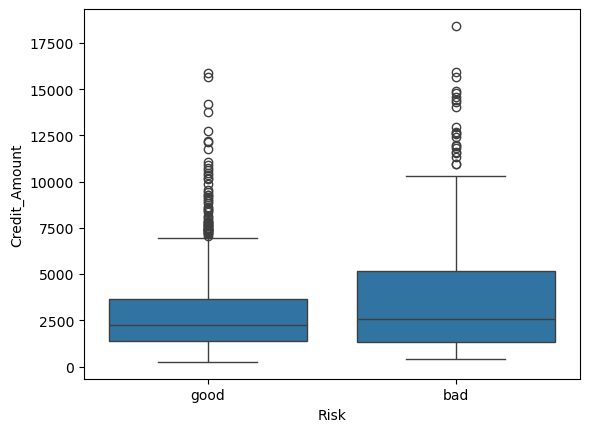

In [34]:
import seaborn as sns
sns.boxplot(x='Risk', y='Credit_Amount', data=df)
### Insight: Nasabah dengan risiko bad cenderung memiliki nilai kredit yang lebih tinggi dan variasi yang lebih besar dibandingkan dengan nasabah good. Hal ini menunjukkan bahwa jumlah pinjaman yang besar dapat meningkatkan potensi risiko gagal bayar.

<Axes: xlabel='Risk', ylabel='Duration'>

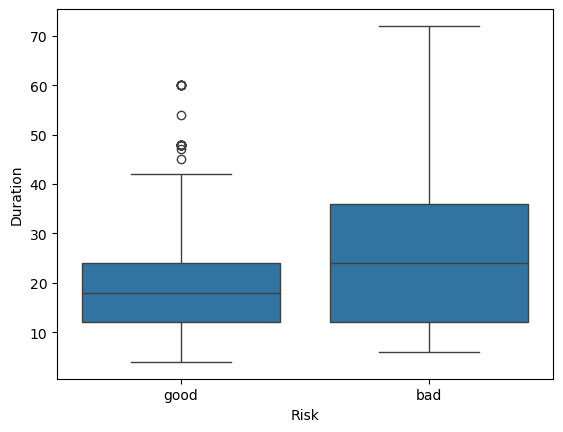

In [35]:
sns.boxplot(x='Risk', y='Duration', data=df)
### Insight: Durasi kredit yang lebih panjang berkaitan dengan peningkatan risiko gagal bayar. Nasabah dalam kategori bad memiliki median durasi yang lebih tinggi dibandingkan dengan kategori good.

In [36]:
pd.crosstab([df['Savings'], df['Housing']], df['Risk'], normalize='index')
### Insight: Nasabah dengan tabungan rendah dan tidak memiliki rumah sendiri menunjukkan proporsi risiko yang lebih tinggi. Sebaliknya, nasabah dengan tabungan tinggi dan memiliki rumah sendiri cenderung memiliki risiko yang jauh lebih rendah.

Risk                      bad      good
Savings     Housing                    
100-500 DM  free     0.500000  0.500000
            own      0.267606  0.732394
            rent     0.454545  0.545455
500-1000 DM free     0.333333  0.666667
            own      0.155556  0.844444
            rent     0.166667  0.833333
<100 DM     free     0.447761  0.552239
            own      0.316279  0.683721
            rent     0.481132  0.518868
>=1000 DM   free     1.000000  0.000000
            own      0.081081  0.918919
            rent     0.111111  0.888889
no_savings  free     0.217391  0.782609
            own      0.161538  0.838462
            rent     0.200000  0.800000

In [33]:
pd.crosstab([df['Job'], df['Savings']], df['Risk'], normalize='index')

Risk                                                bad      good
Job                               Savings                        
highly_skilled                    100-500 DM   0.500000  0.500000
                                  500-1000 DM  0.000000  1.000000
                                  <100 DM      0.385417  0.614583
                                  >=1000 DM    0.333333  0.666667
                                  no_savings   0.206897  0.793103
skilled                           100-500 DM   0.272727  0.727273
                                  500-1000 DM  0.166667  0.833333
                                  <100 DM      0.368852  0.631148
                                  >=1000 DM    0.138889  0.861111
                                  no_savings   0.175000  0.825000
unemployed/unskilled_non_resident 500-1000 DM  0.000000  1.000000
                                  <100 DM      0.461538  0.538462
                                  >=1000 DM    0.000000  1.000000
                                  no_savings   0.200000  0.800000
unskilled_resident                100-500 DM   0.391304  0.608696
                                  500-1000 DM  0.333333  0.666667
                                  <100 DM      0.304688  0.695312
                                  >=1000 DM    0.000000  1.000000
                                  no_savings   0.137931  0.862069

In [34]:
df

,Status,Duration,Credit_History,Purpose,Credit_Amount,Savings,Employment_Duration,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Number_Credits,Job,People_Liable,Telephone,Foreign_Worker,Risk
0,<0 DM,6,A34,A43,1169,no_savings,A75,4,A93,A101,...,A121,67,A143,own,2,skilled,1,A192,A201,good
1,0-200 DM,48,A32,A43,5951,<100 DM,A73,2,A92,A101,...,A121,22,A143,own,1,skilled,1,A191,A201,bad
2,no_account,12,A34,A46,2096,<100 DM,A74,2,A93,A101,...,A121,49,A143,own,1,unskilled_resident,2,A191,A201,good
3,<0 DM,42,A32,A42,7882,<100 DM,A74,2,A93,A103,...,A122,45,A143,free,1,skilled,2,A191,A201,good
4,<0 DM,24,A33,A40,4870,<100 DM,A73,3,A93,A101,...,A124,53,A143,free,2,skilled,2,A191,A201,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no_account,12,A32,A42,1736,<100 DM,A74,3,A92,A101,...,A121,31,A143,own,1,unskilled_resident,1,A191,A201,good
996,<0 DM,30,A32,A41,3857,<100 DM,A73,4,A91,A101,...,A122,40,A143,own,1,highly_skilled,1,A192,A201,good
997,no_account,12,A32,A43,804,<100 DM,A75,4,A93,A101,...,A123,38,A143,own,1,skilled,1,A191,A201,good
998,<0 DM,45,A32,A43,1845,<100 DM,A73,4,A93,A101,...,A124,23,A143,free,1,skilled,1,A192,A201,bad


In [37]:
df['Duration_bin'] = pd.cut(df['Duration'], bins=[0,12,24,36,72])

pd.crosstab([df['Status'], df['Duration_bin']], df['Risk'], normalize='index')
### Insight: Nasabah dengan saldo rendah atau negatif dan durasi kredit yang panjang memiliki probabilitas risiko yang jauh lebih tinggi. Sebaliknya, nasabah dengan kondisi rekening baik dan durasi pendek menunjukkan risiko yang sangat rendah.

Risk                          bad      good
Status     Duration_bin                    
0-200 DM   (0, 12]       0.296703  0.703297
           (12, 24]      0.346939  0.653061
           (24, 36]      0.522727  0.477273
           (36, 72]      0.583333  0.416667
<0 DM      (0, 12]       0.358696  0.641304
           (12, 24]      0.508475  0.491525
           (24, 36]      0.578947  0.421053
           (36, 72]      0.769231  0.230769
>=200 DM   (0, 12]       0.166667  0.833333
           (12, 24]      0.291667  0.708333
           (24, 36]      0.285714  0.714286
           (36, 72]      0.000000  1.000000
no_account (0, 12]       0.075342  0.924658
           (12, 24]      0.122807  0.877193
           (24, 36]      0.185185  0.814815
           (36, 72]      0.173913  0.826087

In [ ]:
### EDA Summary:
Dari hasil eksplorasi data, ditemukan bahwa faktor utama yang mempengaruhi risiko kredit adalah:
- Status rekening (checking account)
- Tingkat tabungan (savings)
- Durasi kredit (duration)
- Jumlah kredit (credit amount)

Selain itu, kombinasi antar variabel menunjukkan bahwa risiko kredit bersifat non-linear dan dipengaruhi oleh interaksi beberapa faktor sekaligus.

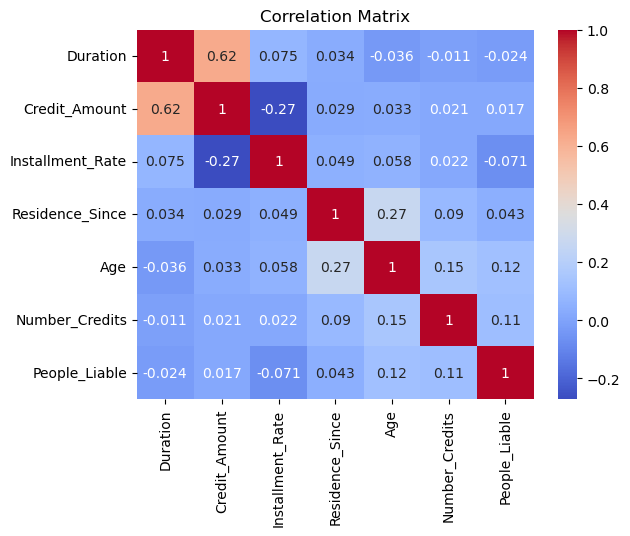

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [39]:
# Risk profilling

df['Risk_Profile'] = 'Medium'

# High Risk
df.loc[
    (df['Status'] == '<0 DM') &
    (df['Savings'] == '<100 DM') &
    (df['Duration'] > 24),
    'Risk_Profile'
] = 'High'

# Low Risk
df.loc[
    (df['Status'].isin(['>=200 DM','no_account'])) &
    (df['Savings'].isin(['>=1000 DM','500-1000 DM'])) &
    (df['Duration'] <= 12) &
    (df['Housing'] == 'own'),
    'Risk_Profile'
] = 'Low'

In [40]:
pd.crosstab(df['Risk_Profile'], df['Risk'], normalize='index')

Risk,bad,good
Risk_Profile,,
High,0.672727,0.327273
Low,0.117647,0.882353
Medium,0.281250,0.718750


In [41]:
df['Risk_Profile'].value_counts()

Risk_Profile
Medium    928
High       55
Low        17
Name: count, dtype: int64

In [42]:
# MODELLING

# Tentukan variabel prediktor dan respon
X = df.drop(columns=['Risk', 'Risk_Profile'])
y = df['Risk'].map({'bad':1, 'good':0})

In [43]:
# Encoding
X = pd.get_dummies(X, drop_first=True)

In [44]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [45]:
# Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
# Model 1: Logistic Regression

from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_log = logreg.predict(X_test_scaled)
LogisticRegression(class_weight='balanced')


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [47]:
feature_names = X.columns

coef = pd.Series(logreg.coef_[0], index=feature_names)
coef.sort_values(ascending=False)

Duration                                 0.552132
Housing_rent                             0.518142
Property_A124                            0.435805
Installment_Rate                         0.380204
Housing_own                              0.361564
Credit_Amount                            0.359141
Status_<0 DM                             0.180800
Savings_<100 DM                          0.161940
People_Liable                            0.134641
Purpose_A46                              0.120213
Number_Credits                           0.097447
Property_A123                            0.083120
Other_Debtors_A102                       0.072449
Job_unskilled_resident                   0.061882
Job_skilled                              0.058611
Property_A122                            0.056403
Duration_bin_(12, 24]                    0.039880
Purpose_A45                              0.020478
Residence_Since                         -0.002476
Age                                     -0.035893


In [49]:
# Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
RandomForestClassifier(class_weight='balanced')


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [53]:
# Threshold Turning for Logistic Reg & Evaluation
from sklearn.metrics import classification_report
y_prob_log = logreg.predict_proba(X_test_scaled)[:,1]

for t in [0.5, 0.4, 0.3]:
    y_pred = (y_prob_log > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       140
           1       0.62      0.55      0.58        60

    accuracy                           0.77       200
   macro avg       0.72      0.70      0.71       200
weighted avg       0.76      0.77      0.76       200


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       140
           1       0.61      0.70      0.65        60

    accuracy                           0.78       200
   macro avg       0.74      0.75      0.74       200
weighted avg       0.79      0.78      0.78       200


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.88      0.71      0.79       140
           1       0.54      0.78      0.64        60

    accuracy                           0.73       200
   macro avg       0.71      0.75      0.71       200
weighted avg       0.78   

In [54]:
# Threshold Turning for Random Forest & Evaluation
rf.fit(X_train, y_train)

y_prob_rf = rf.predict_proba(X_test)[:,1]

from sklearn.metrics import classification_report

for t in [0.5, 0.4, 0.3]:
    y_pred = (y_prob_rf > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       140
           1       0.66      0.42      0.51        60

    accuracy                           0.76       200
   macro avg       0.72      0.66      0.68       200
weighted avg       0.75      0.76      0.74       200


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       140
           1       0.55      0.60      0.58        60

    accuracy                           0.73       200
   macro avg       0.69      0.70      0.69       200
weighted avg       0.74      0.73      0.74       200


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.89      0.64      0.75       140
           1       0.49      0.82      0.62        60

    accuracy                           0.69       200
   macro avg       0.69      0.73      0.68       200
weighted avg       0.77   

In [55]:
# ROC-AUC
y_prob_log = logreg.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("ROC Logistic:", roc_auc_score(y_test, y_prob_log))
print("ROC RF:", roc_auc_score(y_test, y_prob_rf))

ROC Logistic: 0.7902380952380952
ROC RF: 0.7950595238095237


<Axes: >

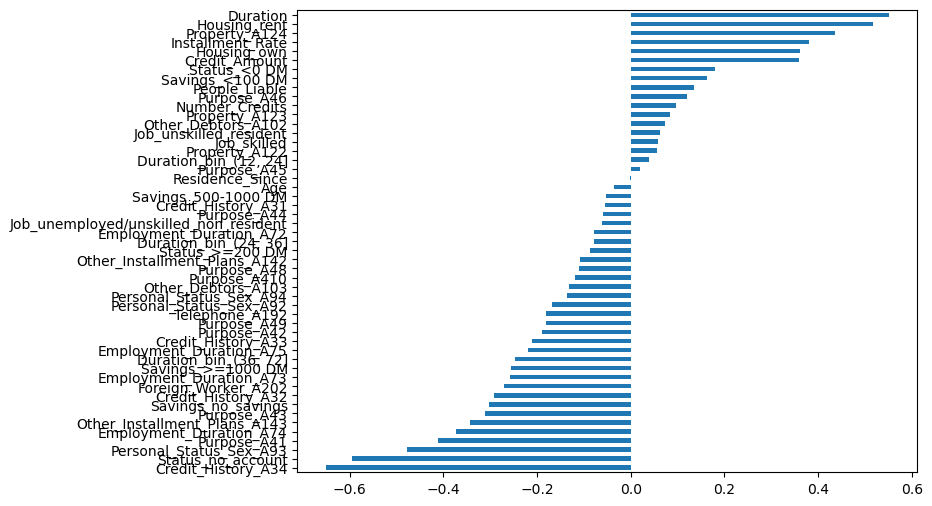

In [56]:
#  Logistic Coef
coef = pd.Series(logreg.coef_[0], index=X.columns)
coef.sort_values().plot(kind='barh', figsize=(8,6))

<Axes: >

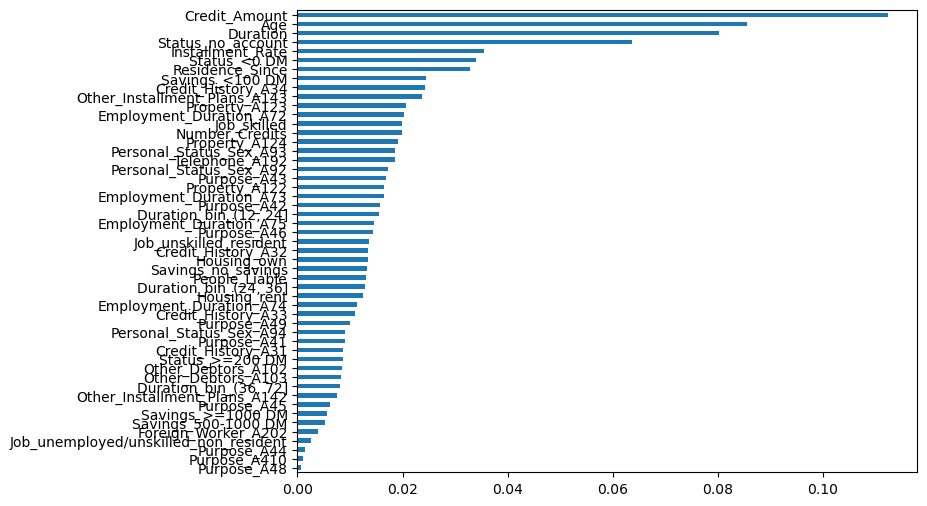

In [57]:
# Random Forest
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))

<Axes: >

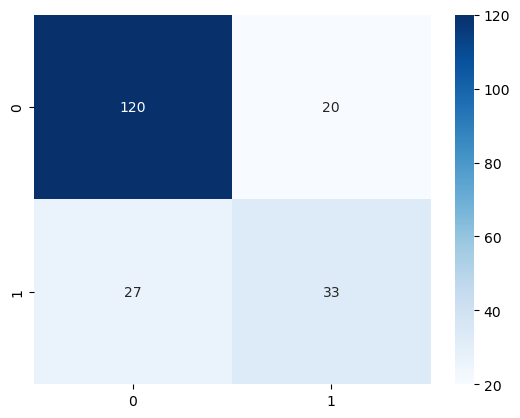

In [58]:
# Confussion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')